<a href="https://colab.research.google.com/github/rohillatanisha676-del/Machine-learning/blob/main/Heart_Diseases_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Diseases Prediction - Machine Learning Project

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Data Handling and Preprocessing

In [4]:
df = pd.read_csv("heart.csv")
print("First 5 rows:\n", df.head())


First 5 rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


## **0 = No Disease,1 = Disease**

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
print("\nDataset Info:\n")
print(df.info())



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


DATA PREPROCESSING

In [8]:
cols = ['sex', 'cp', 'trestbps', 'chol', 'fbs' , 'restecg']

print("Zero values BEFORE preprocessing:\n")
for col in cols:
    print(col, ":", (df[col] == 0).sum())


Zero values BEFORE preprocessing:

sex : 312
cp : 497
trestbps : 0
chol : 0
fbs : 872
restecg : 497


In [9]:
df[cols] = df[cols].replace(0, np.nan)

print("\nMissing values AFTER replacing 0 with NaN:\n")
print(df.isnull().sum())


Missing values AFTER replacing 0 with NaN:

age           0
sex         312
cp          497
trestbps      0
chol          0
fbs         872
restecg     497
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64


In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing values AFTER filling:\n")
print(df.isnull().sum())



Missing values AFTER filling:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# Train/Test Split

In [12]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Logistic Regression
# Model Development and Training

In [14]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n--- Logistic Regression (Base Model) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


--- Logistic Regression (Base Model) ---
Accuracy: 0.7365853658536585
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.66      0.71       102
           1       0.71      0.82      0.76       103

    accuracy                           0.74       205
   macro avg       0.74      0.74      0.73       205
weighted avg       0.74      0.74      0.73       205

Confusion Matrix:
 [[67 35]
 [19 84]]


# Hyperparameter Tuning – Logistic Regression

In [22]:
# FIX: GridSearchCV for Logistic Regression was missing in the original notebook
param_grid_lr = {'C': [0.1, 1.0, 10.0]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)

Best LR params: {'C': 0.1}


In [23]:
# FIX: Renamed best_lr_score to avoid conflict with best_lr model variable used later
lr_results = pd.DataFrame(grid.cv_results_)
lr_results = lr_results[['param_C', 'mean_test_score']]
lr_results.columns = ['C', 'Accuracy']

lr_results['Trial ID'] = ['LR_' + str(i+1).zfill(2) for i in range(len(lr_results))]

best_lr_score = lr_results['Accuracy'].max()  # FIX: renamed from best_lr
lr_results['Status'] = lr_results['Accuracy'].apply(
    lambda x: "Best" if x == best_lr_score else "Better" if x > best_lr_score - 0.01 else "Baseline"
)

lr_results = lr_results[['Trial ID', 'C', 'Accuracy', 'Status']]

print("\n===== Logistic Regression Trials =====")
print(lr_results)


===== Logistic Regression Trials =====
  Trial ID       C  Accuracy    Status
0    LR_01    0.01  0.776829  Baseline
1    LR_02    0.01  0.821951    Better
2    LR_03    0.10  0.824390      Best
3    LR_04    0.10  0.819512    Better
4    LR_05    1.00  0.817073    Better
5    LR_06    1.00  0.818293    Better
6    LR_07   10.00  0.818293    Better
7    LR_08   10.00  0.818293    Better
8    LR_09  100.00  0.818293    Better
9    LR_10  100.00  0.818293    Better


# Evaluation and Interpretation

In [24]:
best_lr_model = grid_lr.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7414634146341463


# Confusion Matrics

In [29]:
cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[68 34]
 [19 84]]


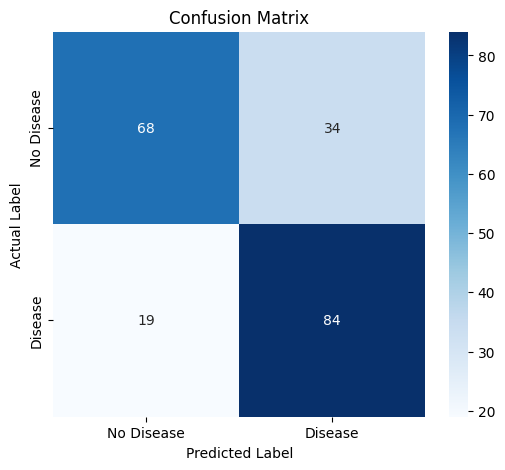

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,         # show numbers
            fmt='d',            # integer format
            cmap='Blues',       # color theme
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

# Accuracy Comparison

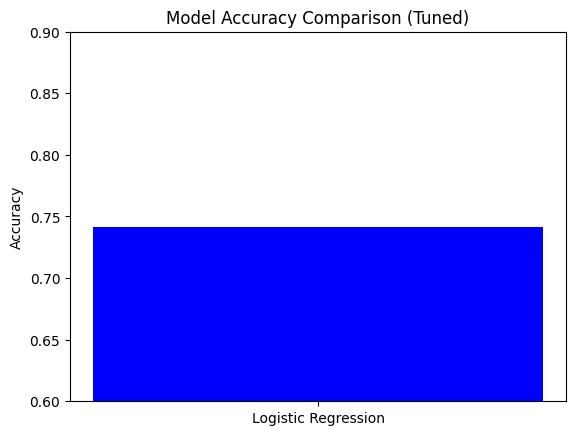

In [34]:
models = ['Logistic Regression']
accuracies = [lr_acc]

plt.figure()
plt.bar(models, accuracies, color=['blue'])
plt.title("Model Accuracy Comparison (Tuned)")
plt.ylabel("Accuracy")
plt.ylim(0.6, 0.9)
plt.show()

# ROC Curves

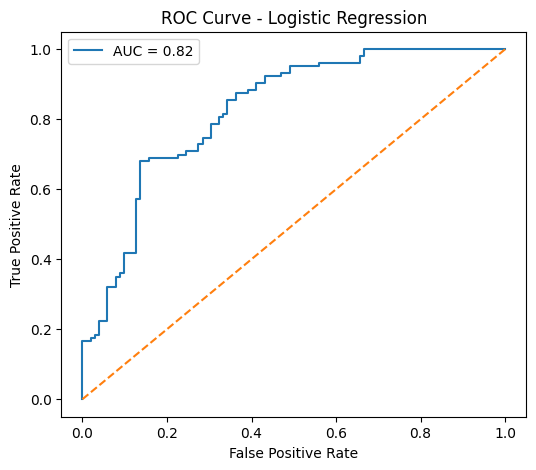

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

# Final leaderboard

In [38]:
from sklearn.metrics import classification_report

# Get classification report for precision, recall, f1-score
report = classification_report(y_test, y_pred_lr, output_dict=True)
precision = report['1']['precision']
recall = report['1']['recall']
f1_score = report['1']['f1-score']

# Collect all metrics into a dictionary or list of dictionaries
results = [{
    "Model": "Logistic Regression",
    "Accuracy": lr_acc,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_score,
    "AUC": auc_score
}]

leaderboard = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"
])
print(leaderboard)

                 Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Logistic Regression  0.741463   0.711864  0.815534  0.760181  0.824957


# Conclusion & Learning Outcomes